# 📊 Your First Data Analysis — From Raw Data to Insight

> **Track:** Introduction Session — Notebook 3 of 3 · **Estimated time:** ~25 min · **Difficulty:** complete beginner

This is the payoff. In Notebook 1 you met Python and notebooks; in Notebook 2 you taught the computer to make decisions and repeat things. Now you'll use those skills to do what data scientists actually do: **take a table of raw data, ask it questions, and turn the answer into a chart.**

## 🎯 Learning objectives

1. See how real-world data lives in **tables** — and how a Python dictionary leads there.
2. Create and inspect a **pandas DataFrame**, the table object of data science.
3. Answer questions with **column statistics, filtering, sorting, and grouping**.
4. Turn a result into a clear **matplotlib chart**.

## ✅ Prerequisites

Notebooks 1 and 2 of the introduction session (variables, f-strings, if-conditions).

## 1. From single values to tables

So far our data has lived in single variables: one name, one number. Real data almost never looks like that. Whether it's patients in a study, survey respondents, or countries in a report — real data comes as a **table**: one row per *thing*, one column per *property*.

Python's stepping stone towards tables is the **dictionary**: labelled data stored as `key: value` pairs. Instead of remembering that "position 2 means population", you ask for `"population_millions"` by name.

In [1]:
# A dictionary stores labelled data: every value gets a name (its "key")
germany = {
    "country": "Germany",
    "continent": "Europe",
    "population_millions": 84.5,
    "internet_users_pct": 93.0,
}

print(germany["country"])
print(f'{germany["population_millions"]} million people live there.')

Germany
84.5 million people live there.


## 2. A table is a dictionary of lists

One dictionary describes **one** country. To describe *twelve*, we flip the idea around: each key becomes a **column name**, and its value becomes a **list** with one entry per country.

The library that turns such a dictionary into a proper table is **pandas** — the tool data scientists reach for every single day. Its table object is called a **DataFrame**.

> ℹ️ The numbers below are **illustrative** — plausible in scale but simplified for teaching. Don't cite them!

In [2]:
import pandas as pd

data = {
    "country": ["Germany", "France", "Estonia", "United States", "Canada", "Brazil",
                "India", "Japan", "South Korea", "Nigeria", "Kenya", "South Africa"],
    "continent": ["Europe", "Europe", "Europe", "Americas", "Americas", "Americas",
                  "Asia", "Asia", "Asia", "Africa", "Africa", "Africa"],
    "population_millions": [84.5, 68.2, 1.4, 335.0, 39.0, 216.0,
                            1430.0, 124.0, 51.7, 224.0, 55.1, 60.4],
    "internet_users_pct": [93.0, 92.0, 92.0, 92.0, 94.0, 84.0,
                           52.0, 84.0, 97.0, 42.0, 40.0, 72.0],
    "ai_startups_per_million": [8.2, 7.5, 15.0, 18.5, 12.4, 2.1,
                                1.2, 3.8, 9.6, 0.4, 0.9, 1.5],
}

df = pd.DataFrame(data)   # "df" is the traditional name for a DataFrame
df                        # the last line of a cell is displayed automatically

,country,continent,population_millions,internet_users_pct,ai_startups_per_million
0,Germany,Europe,84.5,93.0,8.2
1,France,Europe,68.2,92.0,7.5
2,Estonia,Europe,1.4,92.0,15.0
3,United States,Americas,335.0,92.0,18.5
4,Canada,Americas,39.0,94.0,12.4
5,Brazil,Americas,216.0,84.0,2.1
6,India,Asia,1430.0,52.0,1.2
7,Japan,Asia,124.0,84.0,3.8
8,South Korea,Asia,51.7,97.0,9.6
9,Nigeria,Africa,224.0,42.0,0.4


## 3. First look: never analyse what you haven't seen

Rule number one of data analysis: **look at your data before you compute anything.** Three commands give you a first impression:

- `df.head()` — the first few rows: *is this the data I think it is?*
- `len(df)` — how many rows (here: countries) are there?
- `df.describe()` — summary statistics for every numeric column

In [3]:
print(f"The table has {len(df)} rows (countries).")
df.head()   # the first 5 rows

The table has 12 rows (countries).


,country,continent,population_millions,internet_users_pct,ai_startups_per_million
0,Germany,Europe,84.5,93.0,8.2
1,France,Europe,68.2,92.0,7.5
2,Estonia,Europe,1.4,92.0,15.0
3,United States,Americas,335.0,92.0,18.5
4,Canada,Americas,39.0,94.0,12.4


In [4]:
df.describe()   # count, mean, spread, min/max — for every numeric column

,population_millions,internet_users_pct,ai_startups_per_million
count,12.000000,12.000000,12.000000
mean,224.108333,77.833333,6.758333
std,391.884720,21.221059,6.120526
min,1.400000,40.000000,0.400000
25%,54.250000,67.000000,1.425000
50%,76.350000,88.000000,5.650000
75%,218.000000,92.250000,10.300000
max,1430.000000,97.000000,18.500000


**Reading `describe()`.** Two things jump out even from this tiny table:

- The **mean** population is about 224 million, but the **median** (the `50%` row) is only about 76 million. A few giants — India, the United States — pull the average up. When mean and median tell different stories, your data is *skewed*: a classic first insight.
- Internet access ranges from **40% to 97%** of the population. That enormous spread is a story in itself — we'll come back to it.

### 🎯 Try it (1–2 min)

Show the **last 3 rows** of the table. The command is the mirror image of `head()` — have a guess before you peek at the solution.

In [5]:
# Your turn 👇

<details><summary>💡 Click to reveal the solution</summary>

```python
df.tail(3)
```

`tail()` shows the *last* rows, just as `head()` shows the first. The number in the parentheses is an *argument* (like the ones you gave functions in Notebook 2): `df.tail(3)` shows 3 rows, plain `df.tail()` defaults to 5.

</details>

## 4. Asking one question: selecting a column

A column answers one question about *all* countries at once — "what share of people are online?". You select it with square brackets and the column's name, exactly like getting a value out of a dictionary. What comes back behaves like a list of numbers with superpowers: it has built-in statistics such as `.mean()` and `.max()`.

In [6]:
internet = df["internet_users_pct"]

print(f"Average internet access : {internet.mean():.1f}%")
print(f"Highest internet access : {internet.max():.1f}%")

# But WHICH country is highest? Sorting will tell us in a minute.

Average internet access : 77.8%
Highest internet access : 97.0%


## 5. Filtering: if-conditions for whole tables

In Notebook 2 you wrote conditions like `if internet_pct >= 90:` to check **one** value. Filtering is the same idea applied to **every row at once**: you write the condition inside the square brackets, and pandas keeps only the rows where it is `True`.

In [7]:
# Which countries have at least 90% of their population online?
well_connected = df[df["internet_users_pct"] >= 90]

print(f"{len(well_connected)} of {len(df)} countries are 'well connected':")
well_connected

6 of 12 countries are 'well connected':


,country,continent,population_millions,internet_users_pct,ai_startups_per_million
0,Germany,Europe,84.5,93.0,8.2
1,France,Europe,68.2,92.0,7.5
2,Estonia,Europe,1.4,92.0,15.0
3,United States,Americas,335.0,92.0,18.5
4,Canada,Americas,39.0,94.0,12.4
8,South Korea,Asia,51.7,97.0,9.6


### 🎯 Try it (1–2 min)

Filter the table to show only the **population giants**: countries with more than 100 million inhabitants. How many are there?

In [8]:
# Your turn 👇

<details><summary>💡 Click to reveal the solution</summary>

```python
giants = df[df["population_millions"] > 100]
print(f"{len(giants)} giants:")
giants
```

The condition `df["population_millions"] > 100` uses exactly the comparison operators from Notebook 2 — only now the comparison runs on the whole column at once, producing a `True`/`False` for every row. Putting that inside `df[...]` keeps the `True` rows: India, the United States, Brazil, Japan, and Nigeria.

</details>

### 💬 Discuss (30 seconds with your neighbour)

Where do you encounter data like this in **your** field — and what would the rows and columns be? Patients and lab values? Historical texts and word counts? Sensors and measurements?

## 6. Sorting and grouping: from rows to insight

Two more verbs and you can answer surprisingly sophisticated questions:

- **`sort_values`** puts rows in order — the top of a sorted table answers *"who is number one?"*.
- **`groupby`** splits the table into groups (here: continents) and computes one number per group. *"What's the average X per Y?"* is the single most common question in data analysis.

In [9]:
# Who has the most AI startups per million inhabitants?
df.sort_values("ai_startups_per_million", ascending=False).head(3)

,country,continent,population_millions,internet_users_pct,ai_startups_per_million
3,United States,Americas,335.0,92.0,18.5
2,Estonia,Europe,1.4,92.0,15.0
4,Canada,Americas,39.0,94.0,12.4


In [10]:
# Average internet access per continent — split, average, done
df.groupby("continent")["internet_users_pct"].mean().round(1).sort_values(ascending=False)

continent
Europe      92.3
Americas    90.0
Asia        77.7
Africa      51.3
Name: internet_users_pct, dtype: float64

**Reading the result.** Twelve rows in, four numbers out — and those four numbers tell a story: in our (illustrative) table, Europe and the Americas average around 90% internet access, Asia sits in the high 70s, and Africa around 51%. That is the *digital divide*, summarised in one line of code.

## 7. The chart: a sentence about data

A table of numbers makes the reader do the work. A good chart **is a sentence about data**: it states *one* message — here, "AI startup density varies enormously between countries" — so clearly that the reader gets it in two seconds. Let's write that sentence with **matplotlib**, Python's standard plotting library.

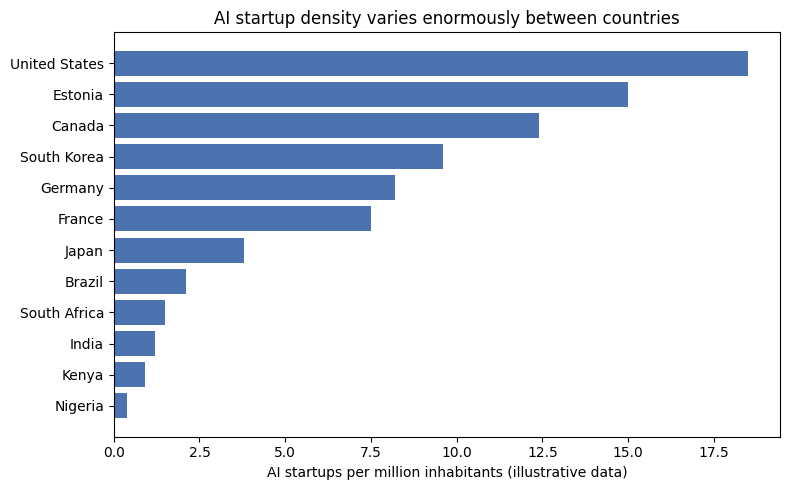

In [11]:
import matplotlib.pyplot as plt

# Sort ascending so the longest bar ends up at the TOP of the chart
by_density = df.sort_values("ai_startups_per_million")

plt.figure(figsize=(8, 5))
plt.barh(by_density["country"], by_density["ai_startups_per_million"], color="#4C72B0")
plt.xlabel("AI startups per million inhabitants (illustrative data)")
plt.title("AI startup density varies enormously between countries")
plt.tight_layout()
plt.show()

### 🎯 Try it (1–2 min)

Make the same chart for **internet access** instead: copy the cell above and change the column to `"internet_users_pct"` (it appears once in `sort_values` and once in `plt.barh`). Update the axis label and title too — a chart with the wrong labels is a false sentence!

In [12]:
# Your turn 👇

<details><summary>💡 Click to reveal the solution</summary>

```python
by_internet = df.sort_values("internet_users_pct")

plt.figure(figsize=(8, 5))
plt.barh(by_internet["country"], by_internet["internet_users_pct"], color="#DD8452")
plt.xlabel("Internet users (% of population, illustrative data)")
plt.title("Internet access ranges from 40% to 97% across our sample")
plt.tight_layout()
plt.show()
```

Only three kinds of change were needed: the column name (twice), and the words on the chart. The *recipe* — sort, `barh`, label, title — stays identical, which is why copying and adapting working code is a perfectly professional habit.

</details>

### 💬 Discuss (30 seconds)

What could be **misleading** about comparing countries this way? Some starters: who counted the "AI startups", and would every country count the same way? Is "per million inhabitants" fair to a very small country like Estonia? What might a single national average hide (cities vs. countryside, young vs. old)?

There's no trick answer — every real analysis inherits the strengths *and* the blind spots of its data. Asking these questions is part of the job.

## 🚀 Where to go from here

Take a second to appreciate what just happened: **90 minutes ago you may never have written a line of Python — and you just completed a real data analysis.** You built a table, inspected it, filtered it, grouped it, and turned it into a chart. That loop — *data → questions → chart* — is the daily rhythm of data science; everything else is refinement.

Your self-study path after today is the **`02_advanced_self_learning/`** track: 10 notebooks that revisit Python fundamentals at a gentler, self-paced depth, work through lists, dictionaries, pandas, NumPy, and visualisation, build up to a full **scikit-learn machine-learning workflow**, and finish with a **capstone project** of your own.

Everything — this notebook included — runs in **Google Colab**, a free notebook environment in your browser with nothing to install: open [colab.research.google.com](https://colab.research.google.com) and upload a notebook, or open it straight from GitHub.

## 🧠 Key takeaways

1. Real data comes as **tables**. A dictionary of lists is Python's doorway to them, and **pandas** turns it into a `DataFrame`.
2. **Look first**: `df.head()`, `len(df)`, and `df.describe()` before any analysis.
3. `df["column"]` selects one question; `.mean()` and `.max()` answer it.
4. **Filtering** — `df[df["col"] > x]` — is the if-condition of tables.
5. `sort_values` finds the leaders; `groupby` computes one number per category — the most common move in all of data analysis.
6. A chart is a **sentence about data**: one message, honest labels.

## ✅ Self-assessment

- [ ] I can build a small DataFrame from a dictionary of lists.
- [ ] I can inspect a table with `head()`, `len()`, and `describe()` — and say in words what I see.
- [ ] I can select a column and compute its mean and maximum.
- [ ] I can filter rows with a condition.
- [ ] I can sort a table and group it by a category.
- [ ] I can make a labelled bar chart with matplotlib.

## ➡️ Next step

You've completed the introduction session 🎉 Continue with the self-study track: [`../02_advanced_self_learning/01_python_basics.ipynb`](../02_advanced_self_learning/01_python_basics.ipynb).